#### Exercise 9 - Starter - Event Study Staggered Rollout

Use stock market data to estimate the impact of the ex-dividend data on stock prices. The ex-dividend date is the first trading date after the dividend record date. Whoever owns the stock on the record date receives the dividend, so purchasing a dividend-paying stock on the ex-dividend date means you've just missed the payout and now have to wait another quarter (typically) until the next payout.

It's often assumed that if markets are efficient that the value of the company should drop on the ex-dividend date because the company is about to distribute cash that a new buyer would not receive, and that's the longest period for which a new buyer would have to wait for the dividend. Let's test this theory by evaluating the incremental price change (net of market performance) on ex-dividend dates for a select group of dividend-paying stocks. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import statsmodels.formula.api as smf

In [2]:
# These are your event dates for each ticker

ex_dividend_dates = {'XOM':'2025-05-15' ,
                     'JNJ':'2025-05-27',
                     'CVX':'2025-05-19',
                     'PG':'2025-04-21',
                     'PM':'2025-03-20'}

targets = list(ex_dividend_dates.keys())



In [3]:
rawdata = pd.read_csv('https://raw.githubusercontent.com/udacity/causal-inference-foundations/refs/heads/main/Exercise9-event-study-staggered-rollout/data/staggered_rollout_dividends.csv', parse_dates=['date'])
rawdata.head()

,target,VOO,VTI,QQQ,DVY,date,target_ticker
0,0.017554,0.002889,0.002816,0.002267,0.010169,2025-02-18,XOM
1,0.001453,0.002419,0.001421,0.000278,0.004523,2025-02-19,XOM
2,0.015412,-0.004205,-0.005377,-0.004245,-0.002905,2025-02-20,XOM
3,-0.011696,-0.017014,-0.018475,-0.020755,-0.004515,2025-02-21,XOM
4,0.005240,-0.004730,-0.005103,-0.011804,0.002122,2025-02-24,XOM


In [4]:
rawdata['ex_div_date']=rawdata['target_ticker'].map(ex_dividend_dates)
rawdata=rawdata.sort_values(by=['target_ticker', 'date'], ascending=[True, True])

ticker_length=rawdata['target_ticker'].value_counts().sort_index()
t=[]
for k, v in ticker_length.items():
    t+=list(range(1,v+1))
rawdata['t']=t

event_tracker=rawdata[rawdata['date']==rawdata['ex_div_date']]['t']
event_t_0=[]
for i, v in enumerate(event_tracker.values):
    event_t_0+=[v.item()]*ticker_length.iloc[i]
rawdata['event_index']=event_t_0
rawdata['trend']=rawdata['t']-rawdata['event_index']

In [6]:
# TO-DO: From rawdata, create a variable called 'trend' that takes on the value of 0 on the ex dividend date, 
# -1 for the previous trading date, -2 for the one before that, +1 for the following trading date and so on.
# Note that if an ex-dividend date is on a monday, 
# the previous friday (if it is the previous date in the data) should be -1 not -3
# save the dataframe as staggered_df 

staggered_df = rawdata.copy()

staggered_df['ex_div_date']=staggered_df['target_ticker'].map(ex_dividend_dates)
staggered_df=staggered_df.sort_values(by=['target_ticker', 'date'], ascending=[True, True])

ticker_length=staggered_df['target_ticker'].value_counts().sort_index()
t=[]
for k, v in ticker_length.items():
    t+=list(range(1,v+1))
staggered_df['t']=t

event_tracker=staggered_df[staggered_df['date']==staggered_df['ex_div_date']]['t']
event_t_0=[]
for i, v in enumerate(event_tracker.values):
    event_t_0+=[v.item()]*ticker_length.iloc[i]
staggered_df['event_index']=event_t_0
staggered_df['trend']=staggered_df['t']-staggered_df['event_index']

print(staggered_df[staggered_df['trend']==0])
print(staggered_df[staggered_df['trend']==-1])
print(staggered_df[staggered_df['trend']==1])

       target       VOO       VTI       QQQ       DVY       date  \
194 -0.025405  0.001025  0.000786  0.000959  0.001196 2025-05-19   
127  0.002027  0.020548  0.020558  0.023525  0.013889 2025-05-27   
260 -0.028600 -0.023827 -0.023768 -0.024747 -0.017956 2025-04-21   
323 -0.011796 -0.002302 -0.002398 -0.003390 -0.002690 2025-03-20   
61   0.000922  0.004906  0.004077  0.001099  0.013386 2025-05-15   

    target_ticker ex_div_date   t  event_index  trend  
194           CVX  2025-05-19  63           63      0  
127           JNJ  2025-05-27  62           62      0  
260            PG  2025-04-21  62           62      0  
323            PM  2025-03-20  59           59      0  
61            XOM  2025-05-15  62           62      0  
       target       VOO       VTI       QQQ       DVY       date  \
193 -0.001125  0.006449  0.006848  0.004352  0.009813 2025-05-16   
126  0.002162 -0.006753 -0.005859 -0.009261  0.001999 2025-05-23   
259  0.025482  0.001386  0.002091 -0.000180  0.0111

### Estimate event study model

In [15]:
# Estimate the event study model only considering the day of the ex dividend date; 
# do not include any dates after that or split out pre-period dates 

# how many staggered time series are there that have a trading date on the ex-dividend date?
# how many of these dates are unique? 
staggered_df['event']=np.where(staggered_df['trend']==0, 1,0)

subset = staggered_df[(staggered_df['trend']>=-60)&(staggered_df['trend']<=0)]
formula ='target~VOO+VTI+QQQ+DVY+event' 
model = smf.ols(formula=formula, data=subset).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     37.39
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           1.10e-29
Time:                        15:28:02   Log-Likelihood:                 845.62
No. Observations:                 303   AIC:                            -1679.
Df Residuals:                     297   BIC:                            -1657.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0007      0.001      0.793      0.4

In [19]:
# Now include 3 additional trading days past the event date. 
# The model should have dummy variables for -3, -2, -1, 0, 1, 2, and 3


subset = staggered_df[(staggered_df['trend']>=-60)&(staggered_df['trend']<=3)].copy()
subset['pre3']=np.where(subset['trend']==-3,1,0)
subset['pre2']=np.where(subset['trend']==-2,1,0)
subset['pre1']=np.where(subset['trend']==-1,1,0)
subset['post0']=np.where(subset['trend']==0,1,0)
subset['post1']=np.where(subset['trend']==1,1,0)
subset['post2']=np.where(subset['trend']==2,1,0)
subset['post3']=np.where(subset['trend']==3,1,0)

formula = 'target~VOO+VTI+QQQ+DVY+pre3+pre2+pre1+post0+post1+post2+post3' 
model = smf.ols(formula=formula, data=subset).fit()
print(model.summary())

#BONUS: inside the fit() method, you can cluster the standard errors at the subset['date'] level for an even better fit


                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     17.11
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           2.66e-26
Time:                        15:30:47   Log-Likelihood:                 889.88
No. Observations:                 318   AIC:                            -1756.
Df Residuals:                     306   BIC:                            -1711.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0006      0.001      0.681      0.4

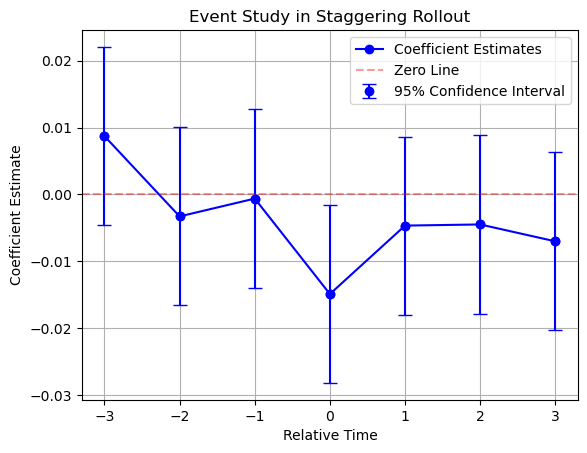

In [20]:
# TO-DO: As you did in previous exercises, plot the coefficients from the model 
# where the x axis goes from -3 to +3 and the y-axis has the coefficient values with standard error bars 
beta_coef = model.params[-7:]
y_errors = model.bse[-7:]*1.96

plt.plot(range(-3, 4), beta_coef, marker='o', color='b', label='Coefficient Estimates')
plt.errorbar(range(-3, 4), beta_coef, yerr=y_errors, fmt='o', color='b', capsize=5, label='95% Confidence Interval')
plt.axhline(0, color='r', linestyle='--', alpha=0.4, label='Zero Line')
plt.xlabel('Relative Time')
plt.ylabel('Coefficient Estimate')
plt.legend(loc='upper right')
plt.title('Event Study in Staggering Rollout')
plt.grid(True)
plt.show()

- All of the other pre and post coefficients are fairly small and have p-values of 0.2 or greater. We also plotted these values and can see that time zero is the only time when the 95% CI doesn't include zero. We can interpret this as saying that all of the loss in value was "soaked up" on the ex-dividend date.